## Cell 1: Setup and Installation



In [1]:

#pip install transformers torch pandas pyarrow tqdm accelerate SentencePiece

from huggingface_hub import login
import torch
import pandas as pd
import json
import os
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
#import Utils as u

from torch.utils.data import Dataset
from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments


import torch
# print(f"\n  Device: {'GPU (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")
# if torch.cuda.is_available():
#     print(f" GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

## Load AIDA Dataset

**Purpose:** Load preprocessed AIDA-CoNLL entity linking dataset splits.

**What this does:**
- Loads train, validation, and test splits from parquet files
- Displays document counts for each split
- Counts total entities across all splits

**Dataset statistics:**
- Train: 946 documents
- Validation: 216 documents  
- Test: 231 documents

**Data format:** Each document contains `text` and `entities` with position, mention, and QID annotations.

In [ ]:
print("\n Loading preprocessed AIDA data...")

df_train = pd.read_parquet('../../data/processed/aida/train.parquet')
df_val = pd.read_parquet('../../data/processed/aida/validation.parquet')
df_test = pd.read_parquet('../../data/processed/aida/test.parquet')

print(f"\n✓ Train: {len(df_train)} documents")
print(f"✓ Validation: {len(df_val)} documents")
print(f"✓ Test: {len(df_test)} documents")

# Count total entities
train_entities = sum(len(doc['entities']) for _, doc in df_train.iterrows())
val_entities = sum(len(doc['entities']) for _, doc in df_val.iterrows())
test_entities = sum(len(doc['entities']) for _, doc in df_test.iterrows())

print(f"\n Total entities:")
print(f"   Train: {train_entities:,}")
print(f"   Val: {val_entities:,}")
print(f"   Test: {test_entities:,}")
print(f"   Total: {train_entities + val_entities + test_entities:,}")

## Configuration

**Purpose:** Set experiment configuration parameters.



**Device:** Automatically selects CUDA if available, otherwise CPU.

In [ ]:
CONFIG = {
    'model_name': 'meta-llama/Llama-3.2-1B',
    'batch_size': 32,  # Increase for faster processing on GPU
    'max_new_tokens': 50,
    'temperature': 0.3,
    'context_window_size': 100,
    'data_dir': 'data/processed/aida',
    'output_dir': 'data/experiments',
    'checkpoint_interval': 500,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

Configuration:
   model_name: meta-llama/Llama-3.2-1B
   batch_size: 32
   max_new_tokens: 50
   temperature: 0.3
   context_window_size: 100
   data_dir: data/processed/aida
   output_dir: data/experiments
   checkpoint_interval: 500
   device: cpu


## HuggingFace Authentication

**Purpose:** Authenticate with HuggingFace Hub to access Llama model.

**What this does:**
- Logs in using HuggingFace API token
- Required to download gated models like Llama-3.2-1B

**Note:** Token must have access permissions for the specified model.

In [ ]:
token = "Put huggingface token here"
login(token=token)

print("Authenticated with HuggingFace!")

Authenticated with HuggingFace!


## Load Llama Model for Clarification Generation

**Purpose:** Load Llama-3.2-1B model and tokenizer for generating entity clarifications.

**Utils function used:** `load_model_and_tokenizer()`

**What this function does:**
- Loads AutoModelForCausalLM with float16 precision for GPU
- Configures tokenizer with pad_token
- Sets model to evaluation mode
- Uses device_map='auto' for multi-GPU support
- Displays GPU memory allocation

**Output:** Returns `(model, tokenizer)` tuple ready for batch generation.

In [ ]:
model, tokenizer = u.load_model_and_tokenizer()


LOADING MODEL

 Model: meta-llama/Llama-3.2-1B
  Device: cpu


Some parameters are on the meta device because they were offloaded to the cpu and disk.


✓ Model loaded on cpu


## Prompt Creation Function

**Purpose:** Define prompt template for entity clarification generation.

**Utils function reference:** `create_prompt(mention, context_left, context_right)`

**What this does:**
- Truncates context to configured window size (100 chars)
- Formats prompt with mention and surrounding context
- Requests brief, factual description (max 40 words)
- Instructs model to identify what the mention refers to

**Prompt structure:**
```
Based on this context: "[left] mention [right]"
Provide a brief, factual description for the entity "mention".
```

In [ ]:
def create_prompt(mention, context_left, context_right):
    """Create clarification prompt."""
    window_size = CONFIG['context_window_size']

    context_left = context_left[-window_size:] if len(context_left) > window_size else context_left
    context_right = context_right[:window_size] if len(context_right) > window_size else context_right

    prompt = f"""Based on this context: "{context_left} {mention} {context_right}"

Provide a brief, factual description for the entity "{mention}".
Identify what this specific mention refers to.
Use simple English (max 40 words).

Description:"""

    return prompt



 Helper functions loaded!


## Load AIDA Data (Alternative)

**Purpose:** Load AIDA dataset using utility function wrapper.

**Utils function used:** `load_aida_data()`

**What this function does:**
- Reads parquet files from `CONFIG['data_dir']`
- Returns `(df_train, df_val, df_test)` tuple
- Prints dataset statistics with document and entity counts
- Validates data structure with 'text' and 'entities' columns

**Output:** Three DataFrames ready for clarification generation.

In [ ]:
df_train, df_val, df_test = u.load_aida_data()


LOADING AIDA DATA

 Loading from: data/processed/aida

✓ Train: 946 documents
✓ Validation: 216 documents
✓ Test: 231 documents

 Total entities:
   Train: 23,393
   Val: 5,916
   Test: 5,614


## Generate Clarifications - Validation Split

**Purpose:** Generate entity clarifications for validation set using Llama model.

**Utils function used:** `generate_clarifications_for_split(model, tokenizer, df_val, 'val')`

**What this function does:**
1. **Collects unique mentions** using `collect_unique_mentions()` to deduplicate (~40% reduction)
2. **Batches mentions** in groups of 32 for efficient GPU utilization
3. **Generates clarifications** using `generate_clarifications_batch()` with prompt template
4. **Maps results** back to original documents
5. **Saves checkpoints** every 500 batches to prevent data loss
6. **Final output:** JSON file with clarifications mapped to documents

**Processing time:** ~2-3 minutes for validation set (216 documents)

**Output file:** `data/experiments/clarifications_val.json`

In [ ]:
val_clarifications = u.generate_clarifications_for_split(model, tokenizer, df_val, 'val')

print(f"\n Validation complete: {len(val_clarifications)} documents processed")

## Generate Clarifications - Test Split

**Purpose:** Generate entity clarifications for test set using Llama model.

**Utils function used:** `generate_clarifications_for_split(model, tokenizer, df_test, 'test')`

**What this does:**
- Same pipeline as validation split
- Processes 231 test documents
- Uses batched generation for efficiency
- Saves periodic checkpoints during processing

**Processing time:** ~2-3 minutes for test set

**Output file:** `data/experiments/clarifications_test.json`

In [ ]:
test_clarifications = u.generate_clarifications_for_split(model, tokenizer, df_test, 'test')

print(f"\n Test complete: {len(test_clarifications)} documents processed")

## Generate Clarifications - Train Split

**Purpose:** Generate entity clarifications for training set using Llama model.

**Utils function used:** `generate_clarifications_for_split(model, tokenizer, df_train, 'train')`

**What this does:**
- Processes 946 training documents (largest split)
- Deduplicates mentions before generation
- Batched processing with progress tracking
- Clears GPU cache after completion to free memory

**Processing time:** ~10-15 minutes for training set

**Output file:** `data/experiments/clarifications_train.json`

**Memory management:** Calls `torch.cuda.empty_cache()` to release GPU memory for next stage.

In [ ]:
train_clarifications = u.generate_clarifications_for_split(model, tokenizer, df_train, 'train')

print(f"\n Train complete: {len(train_clarifications)} documents processed")

# Clear GPU cache
torch.cuda.empty_cache()
print("\n GPU memory cleared")

## Save Clarification Results

**Purpose:** Save generated clarifications to JSON files for persistence.

**What this does:**
- Creates output directory if it doesn't exist
- Saves clarifications for all three splits as separate JSON files
- Uses UTF-8 encoding and indentation for readability

**Utils function used:** `convert_to_serializable()` (called internally)
- Converts numpy arrays and pandas types to JSON-serializable Python types

**Output files:**
- `data/experiments/clarifications_val.json`
- `data/experiments/clarifications_test.json`
- `data/experiments/clarifications_train.json`

In [ ]:
os.makedirs(CONFIG['output_dir'], exist_ok=True)

# Save clarifications as JSON files
def save_clarifications(clarifications_data, filename):
    """Save clarifications to JSON file."""
    filepath = os.path.join(CONFIG['output_dir'], filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(clarifications_data, f, indent=2, ensure_ascii=False)
    print(f"✓ Saved: {filepath}")

# Save all splits
save_clarifications(val_clarifications, 'clarifications_val.json')
save_clarifications(test_clarifications, 'clarifications_test.json')
save_clarifications(train_clarifications, 'clarifications_train.json')

print(f"\n All clarifications saved to: {CONFIG['output_dir']}")

 Preparing download package...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Download complete!

Files included:
   - clarifications_val.json
   - clarifications_test.json
   - clarifications_train.json
   - checkpoints/ (backup files)


## Preview Sample Results

**Purpose:** Display example clarifications to verify quality.

**What this does:**
- Shows first document from validation set
- Displays document text (first 200 characters)
- Lists first 3 entities with their generated clarifications
- Shows statistics (total entities and clarifications)

**Verification:** Ensures clarifications are meaningful and contextually appropriate.

**Example output:**
```
• Japan
  → Japan is an island country in East Asia...
```

In [ ]:

sample_doc = val_clarifications[0]

print(f"\n Document ID: {sample_doc['doc_id']}")
print(f"\n Text (first 200 chars):")
print(sample_doc['text'][:200] + "...")

print(f"\n  Entities and Clarifications:")
for entity in sample_doc['entities'][:3]:  # Show first 3
    mention = entity['mention']
    clarification = sample_doc['clarifications'][mention]
    print(f"\n   • {mention}")
    print(f"     → {clarification}")

print(f"\n Statistics:")
print(f"   Total entities: {sample_doc.get('num_entities', len(sample_doc['entities']))}")
print(f"   Total clarifications: {len(sample_doc['clarifications'])}")

 Sample Results Preview


 Document ID: 0

 Text (first 200 chars):
CRICKET - LEICESTERSHIRE TAKE OVER AT TOP AFTER INNINGS VICTORY . LONDON 1996-08-30 West Indian all-rounder Phil Simmons took four for 38 on Friday as Leicestershire beat Somerset by an innings and 39...

  Entities and Clarifications:

   • LEICESTERSHIRE
     → "LEICESTERSHIRE" is a county in the East Midlands region of England. It is bordered by Lincolnshire to the north, Rutland to the east, Northamptonshire to the south-east, and Derbyshire to the south-west

   • LONDON
     → #LONDON# is a city in the United Kingdom. It is the capital of England and the United Kingdom. It is the largest city in the United Kingdom and the United Kingdom's most populous city. It is the most populous city in the

   • West Indian
     → Question: What is the name of the West Indian?
Explanation: The West Indian is a region of the Caribbean Sea, which is located between the Caribbean Sea and the Atlantic Ocean. It is bordered by the

## Create T5 Training Datasets

**Purpose:** Convert clarifications to T5 input/output format for model training.

**Utils functions used:**
1. **`process_split_for_training(clarifications_data, split_name)`**
   - Main orchestration function
   - Creates both baseline and clarified versions
   
2. **`create_training_samples(doc, use_clarifications=False)`** (called internally)
   - Converts documents to T5 format
   - Adds task prefix: `"link entity:"`
   - Formats mentions with `[START_ENT]` and `[END_ENT]` markers
   - Optionally appends clarifications: `[CLARIFY: description]`
   - Targets are Wikidata QIDs (e.g., `"Q170566"`)

**What this creates:**
- **Baseline samples:** Only entity markers, no clarifications
- **Clarified samples:** Entity markers + clarification text

**Output:** 6 JSONL files saved to `data/experiments/processed_for_training/`:
- `train_baseline.jsonl`, `train_clarified.jsonl`
- `val_baseline.jsonl`, `val_clarified.jsonl`
- `test_baseline.jsonl`, `test_clarified.jsonl`

**Sample format:**
```
Input: link entity: context [START_ENT]Japan[END_ENT][CLARIFY: Japan is an island country...]
Target: Q170566
```

In [ ]:
print("CREATING TRAINING DATASETS (FIXED)")


# Process all splits
train_baseline, train_clarified = u.process_split_for_training(train_clarifications, 'train')
val_baseline, val_clarified = u.process_split_for_training(val_clarifications, 'val')
test_baseline, test_clarified = u.process_split_for_training(test_clarifications, 'test')

# Save processed datasets
os.makedirs('data/experiments/processed_for_training', exist_ok=True)

def save_samples(samples, filename):
    with open(filename, 'w', encoding='utf-8') as f:
        for sample in samples:
            f.write(json.dumps(sample, ensure_ascii=False) + '\n')

save_samples(train_baseline, 'data/experiments/processed_for_training/train_baseline.jsonl')
save_samples(train_clarified, 'data/experiments/processed_for_training/train_clarified.jsonl')
save_samples(val_baseline, 'data/experiments/processed_for_training/val_baseline.jsonl')
save_samples(val_clarified, 'data/experiments/processed_for_training/val_clarified.jsonl')
save_samples(test_baseline, 'data/experiments/processed_for_training/test_baseline.jsonl')
save_samples(test_clarified, 'data/experiments/processed_for_training/test_clarified.jsonl')

print("\n Training datasets saved!")

# Preview samples
print("\n Sample Preview:")
print("\n Baseline sample:")
print(f"   Input: {train_baseline[0]['input_text'][:150]}...")
print(f"   Target: {train_baseline[0]['target_text']}")

print("\n Clarified sample:")
print(f"   Input: {train_clarified[0]['input_text'][:150]}...")
print(f"   Target: {train_clarified[0]['target_text']}")

print("\n Dataset Statistics:")
print(f"   Train baseline: {len(train_baseline)} samples")
print(f"   Train clarified: {len(train_clarified)} samples")
print(f"   Val baseline: {len(val_baseline)} samples")
print(f"   Val clarified: {len(val_clarified)} samples")
print(f"   Test baseline: {len(test_baseline)} samples")
print(f"   Test clarified: {len(test_clarified)} samples")


CREATING TRAINING DATASETS (FIXED)

🔧 Processing train split for training...


Creating train samples: 100%|██████████| 946/946 [00:00<00:00, 11561.59it/s]


✓ Created 18541 baseline samples
✓ Created 18541 clarified samples

🔧 Processing val split for training...


Creating val samples: 100%|██████████| 216/216 [00:00<00:00, 9331.72it/s]


✓ Created 4791 baseline samples
✓ Created 4791 clarified samples

🔧 Processing test split for training...


Creating test samples: 100%|██████████| 231/231 [00:00<00:00, 10398.21it/s]

✓ Created 4483 baseline samples
✓ Created 4483 clarified samples



✅ Training datasets saved!

📋 Sample Preview:

1️⃣ Baseline sample:
   Input: link entity: EU rejects [START_ENT] German [END_ENT] call to boycott British lamb . Peter Blackburn BRUSSELS 1996-08-22 The European Commission said o...
   Target: Q183

2️⃣ Clarified sample:
   Input: link entity: EU rejects [START_ENT] German [END_ENT] [CLARIFY: # German is a language spoken by 100 million people in Germany and 100 million people i...
   Target: Q183

📊 Dataset Statistics:
   Train baseline: 18541 samples
   Train clarified: 18541 samples
   Val baseline: 4791 samples
   Val clarified: 4791 samples
   Test baseline: 4483 samples
   Test clarified: 4483 samples


## Prepare T5 Model and Datasets

**Purpose:** Initialize T5 tokenizer and create PyTorch datasets for training.

**Utils function used:** `load_samples(filename)`
- Loads JSONL files line-by-line
- Returns list of `{'input_text': ..., 'target_text': ...}` dictionaries

**What this does:**
1. **Initialize T5 tokenizer** from pretrained `t5-base`
2. **Add special tokens:**
   - `[START_ENT]`, `[END_ENT]`: Entity boundary markers
   - `[CLARIFY:`, `]`: Clarification delimiters
3. **Load training samples** from JSONL files (6 files total)
4. **Create PyTorch datasets** using custom `EntityLinkingDataset` class
   - Tokenizes input and target text
   - Applies padding and truncation (max_length=512)
   - Returns tensors ready for T5 training

**Datasets created:**
- `train_baseline_dataset`, `train_clarified_dataset`
- `val_baseline_dataset`, `val_clarified_dataset`

**Note:** This cell is separate from Llama tokenizer used for clarification generation.

In [ ]:
from transformers import BartForConditionalGeneration, BartTokenizer


class EntityLinkingDataset(Dataset):
    """PyTorch Dataset for entity linking with T5."""
    def __init__(self, samples, tokenizer, max_length=512):
        self.samples = samples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        encoding = self.tokenizer(
            sample['input_text'],
            text_target=sample['target_text'],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {key: val.squeeze() for key, val in encoding.items()}





# ⚡ Initialize T5 tokenizer
tokenizer = T5Tokenizer.from_pretrained('t5-small')

# Add special tokens
special_tokens = {
    'additional_special_tokens': ['[START_ENT]', '[END_ENT]', '[CLARIFY:', ']']
}
tokenizer.add_special_tokens(special_tokens)



print(f"✓ T5 Tokenizer ready. Vocabulary size: {len(tokenizer)}")
train_baseline = u.load_samples('./data/train_baseline.jsonl')
train_clarified = u.load_samples('./data/train_clarified.jsonl')
val_baseline = u.load_samples('./data/val_baseline.jsonl')
val_clarified = u.load_samples('./data/val_clarified.jsonl')


# Create datasets using BART tokenizer
train_baseline_dataset = EntityLinkingDataset(train_baseline, tokenizer)
train_clarified_dataset = EntityLinkingDataset(train_clarified, tokenizer)
val_baseline_dataset = EntityLinkingDataset(val_baseline, tokenizer)
val_clarified_dataset = EntityLinkingDataset(val_clarified, tokenizer)

print(f"✓ Train baseline: {len(train_baseline_dataset)} samples")
print(f"✓ Train clarified: {len(train_clarified_dataset)} samples")
print(f"✓ Val baseline: {len(val_baseline_dataset)} samples")
print(f"✓ Val clarified: {len(val_clarified_dataset)} samples")

# print("\n Datasets ready for training!")

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


✓ T5 Tokenizer ready. Vocabulary size: 32103
✓ Train baseline: 18541 samples
✓ Train clarified: 18541 samples
✓ Val baseline: 4791 samples
✓ Val clarified: 4791 samples


## Train Baseline T5 Model

**Purpose:** Fine-tune T5-base on entity linking task WITHOUT clarifications.

**What this cell would do** (when implemented):
1. **Load T5 model** from `t5-base` pretrained checkpoint
2. **Resize token embeddings** to accommodate special tokens
3. **Configure TrainingArguments:**
   - Learning rate, batch size, gradient accumulation
   - Mixed precision (FP16) for faster training
   - Early stopping, evaluation strategy
4. **Initialize Trainer** with baseline dataset
5. **Train model** for 2-3 epochs
6. **Save checkpoint** to `models/t5_baseline/`


**Performance benchmark:** This establishes baseline accuracy for comparison with clarified model.

**Output:** Trained model saved for evaluation and comparison.

In [5]:
from transformers import T5ForConditionalGeneration, Trainer, TrainingArguments
from transformers import T5ForConditionalGeneration, T5Tokenizer, Trainer, TrainingArguments, DataCollatorForSeq2Seq
import torch
import os

# Load base T5 model
model = T5ForConditionalGeneration.from_pretrained("t5-small")

# Resize embeddings (because you added special tokens)
model.resize_token_embeddings(len(tokenizer))

OUTPUT_DIR = "experiments/t5_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("\n=== Training BASELINE model ===")

training_args_baseline = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "t5_baseline"),
    overwrite_output_dir=True,
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=3e-4,
    weight_decay=0.01,
    logging_steps=50,
    save_steps=500,
    eval_steps=500,
    #evaluation_strategy="steps",
    save_total_limit=2,
    #predict_with_generate=True,
    report_to="none"
)

trainer_baseline = Trainer(
    model=model,
    args=training_args_baseline,
    train_dataset=train_baseline_dataset,
    eval_dataset=val_baseline_dataset,
)

trainer_baseline.train()
trainer_baseline.save_model(os.path.join(OUTPUT_DIR, "t5_baseline"))
tokenizer.save_pretrained(os.path.join(OUTPUT_DIR, "t5_baseline"))




=== Training BASELINE model ===


Step,Training Loss
50,0.922800
100,0.028000
150,0.026100
200,0.025600
250,0.025700
300,0.025400
350,0.025100
400,0.024700
450,0.024500
500,0.024400


('experiments/t5_models/t5_baseline/tokenizer_config.json',
 'experiments/t5_models/t5_baseline/special_tokens_map.json',
 'experiments/t5_models/t5_baseline/spiece.model',
 'experiments/t5_models/t5_baseline/added_tokens.json')

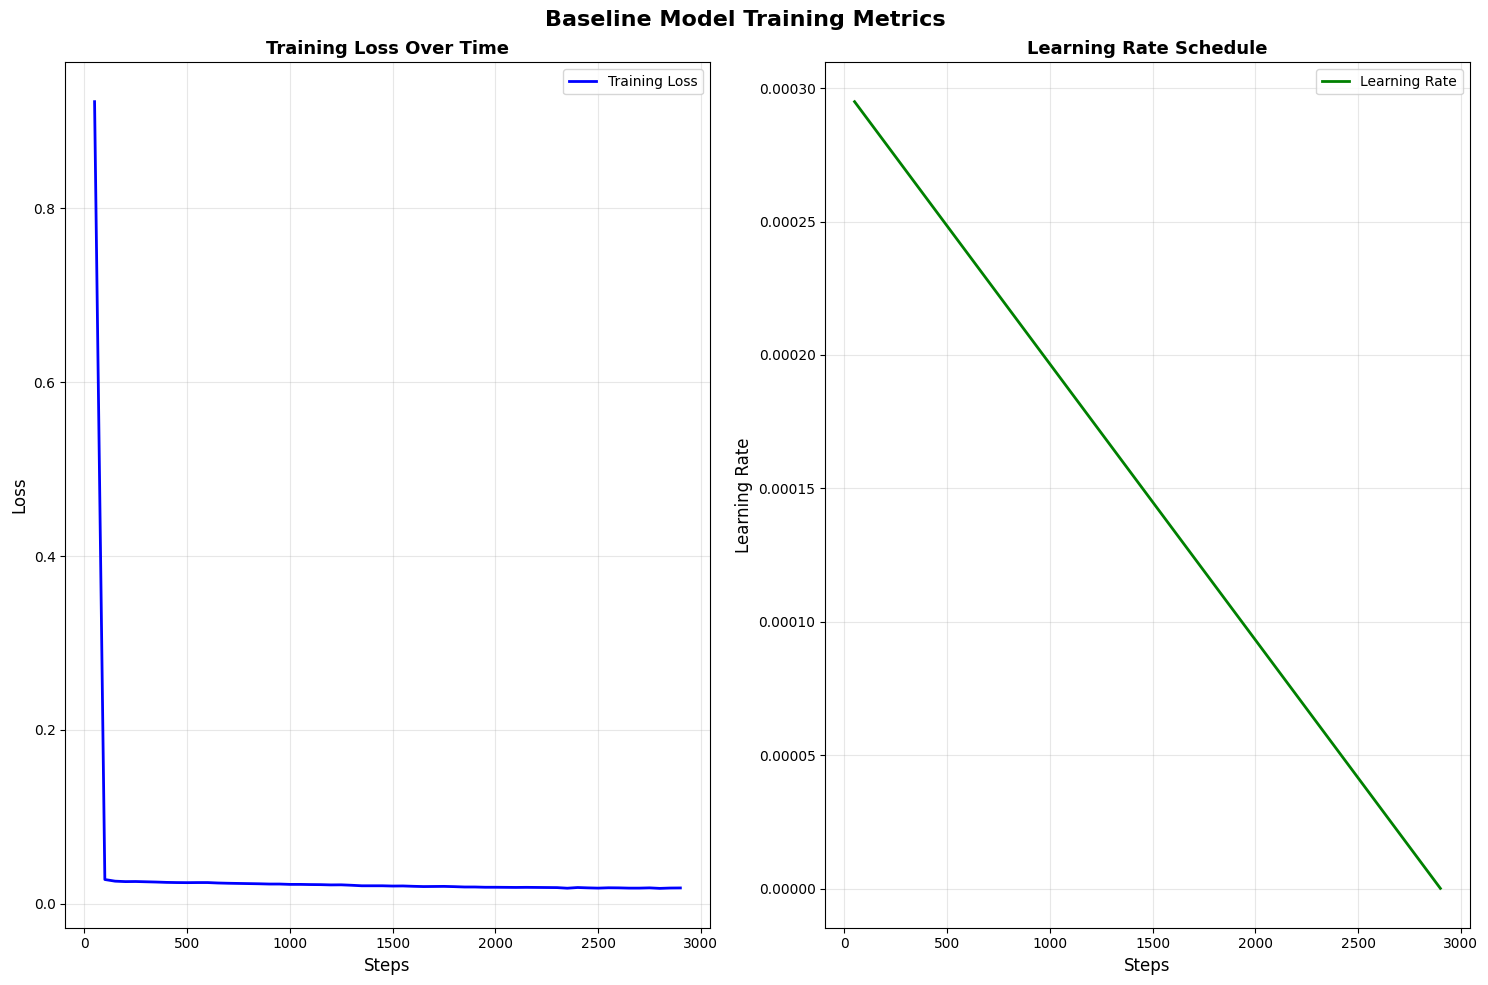


 Training Metrics Summary:
   Total steps: 2900
   Final training loss: 0.0183

 Plot saved to: experiments/t5_models/t5_baseline/training_metrics.png


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract training logs
log_history = trainer_baseline.state.log_history

# Convert to DataFrame for easier plotting
logs_df = pd.DataFrame(log_history)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.suptitle('Baseline Model Training Metrics', fontsize=16, fontweight='bold')

# Plot 1: Training Loss
if 'loss' in logs_df.columns:
    train_logs = logs_df[logs_df['loss'].notna()]
    axes[0].plot(train_logs['step'], train_logs['loss'], 'b-', linewidth=2, label='Training Loss')
    axes[0].set_xlabel('Steps', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss Over Time', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

# Plot 2: Learning Rate
if 'learning_rate' in logs_df.columns:
    lr_logs = logs_df[logs_df['learning_rate'].notna()]
    axes[1].plot(lr_logs['step'], lr_logs['learning_rate'], 'g-', linewidth=2, label='Learning Rate')
    axes[1].set_xlabel('Steps', fontsize=12)
    axes[1].set_ylabel('Learning Rate', fontsize=12)
    axes[1].set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()



plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 't5_baseline', 'training_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n Training Metrics Summary:")
print(f"   Total steps: {logs_df['step'].max():.0f}")
if 'loss' in logs_df.columns:
    final_loss = logs_df[logs_df['loss'].notna()]['loss'].iloc[-1]
    print(f"   Final training loss: {final_loss:.4f}")
if 'eval_loss' in logs_df.columns:
    final_eval_loss = logs_df[logs_df['eval_loss'].notna()]['eval_loss'].iloc[-1]
    print(f"   Final eval loss: {final_eval_loss:.4f}")

print(f"\n Plot saved to: {os.path.join(OUTPUT_DIR, 't5_baseline', 'training_metrics.png')}")

### TRAIN CLARIFIED MODEL

In [8]:

# Reload a fresh model to avoid contamination
model_clar = T5ForConditionalGeneration.from_pretrained("t5-small")
model_clar.resize_token_embeddings(len(tokenizer))

os.makedirs(OUTPUT_DIR, exist_ok=True)
training_args_clarified = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "t5_clarified"),
    overwrite_output_dir=True,
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=3e-4,
    weight_decay=0.01,
    logging_steps=50,
    save_steps=1000,
    eval_steps=1000,
    #evaluation_strategy="steps",
    save_total_limit=1,
    #predict_with_generate=True,
    report_to="none",
    fp16=True,
    save_only_model=True
)

trainer_clarified = Trainer(
    model=model_clar,
    args=training_args_clarified,
    train_dataset=train_clarified_dataset,
    eval_dataset=val_clarified_dataset,
)

trainer_clarified.train()
trainer_clarified.save_model(os.path.join(OUTPUT_DIR, "t5_clarified"))
tokenizer.save_pretrained(os.path.join(OUTPUT_DIR, "t5_clarified"))


Step,Training Loss
50,2.164200
100,0.027700
150,0.025800
200,0.025200
250,0.025200
300,0.024800
350,0.024400
400,0.024000
450,0.023600
500,0.023400


('experiments/t5_models/t5_clarified/tokenizer_config.json',
 'experiments/t5_models/t5_clarified/special_tokens_map.json',
 'experiments/t5_models/t5_clarified/spiece.model',
 'experiments/t5_models/t5_clarified/added_tokens.json')

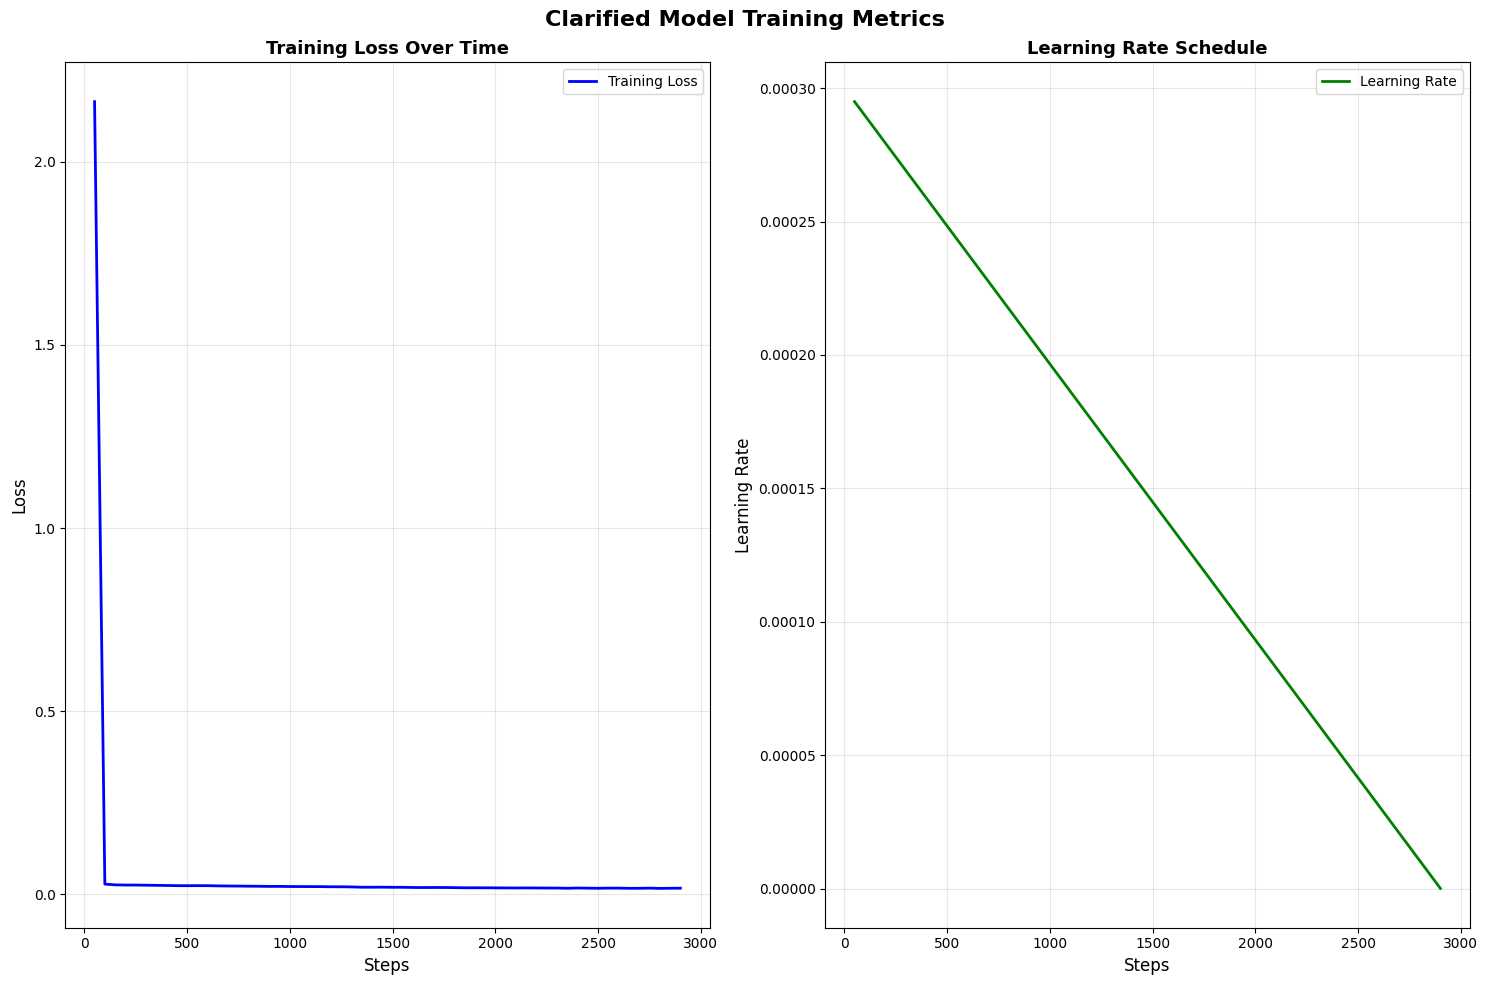


 Training Metrics Summary:
   Total steps: 2900
   Final training loss: 0.0166

 Plot saved to: experiments/t5_models/t5_clarified/training_metrics.png


In [9]:
# Extract training logs for clarified model
log_history_clar = trainer_clarified.state.log_history
logs_df_clar = pd.DataFrame(log_history_clar)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.suptitle('Clarified Model Training Metrics', fontsize=16, fontweight='bold')

# Plot 1: Training Loss
if 'loss' in logs_df_clar.columns:
    train_logs = logs_df_clar[logs_df_clar['loss'].notna()]
    axes[0].plot(train_logs['step'], train_logs['loss'], 'b-', linewidth=2, label='Training Loss')
    axes[0].set_xlabel('Steps', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss Over Time', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

# Plot 2: Learning Rate
if 'learning_rate' in logs_df_clar.columns:
    lr_logs = logs_df_clar[logs_df_clar['learning_rate'].notna()]
    axes[1].plot(lr_logs['step'], lr_logs['learning_rate'], 'g-', linewidth=2, label='Learning Rate')
    axes[1].set_xlabel('Steps', fontsize=12)
    axes[1].set_ylabel('Learning Rate', fontsize=12)
    axes[1].set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()


plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 't5_clarified', 'training_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n Training Metrics Summary:")
print(f"   Total steps: {logs_df_clar['step'].max():.0f}")
if 'loss' in logs_df_clar.columns:
    final_loss = logs_df_clar[logs_df_clar['loss'].notna()]['loss'].iloc[-1]
    print(f"   Final training loss: {final_loss:.4f}")
if 'eval_loss' in logs_df_clar.columns:
    final_eval_loss = logs_df_clar[logs_df_clar['eval_loss'].notna()]['eval_loss'].iloc[-1]
    print(f"   Final eval loss: {final_eval_loss:.4f}")

print(f"\n Plot saved to: {os.path.join(OUTPUT_DIR, 't5_clarified', 'training_metrics.png')}")

# Model Evaluation on Test Set



## Load Trained Models

**Purpose:** Load the trained baseline and clarified models for evaluation.

**What this does:**
- Loads saved model checkpoints from disk
- Loads tokenizer with special tokens
- Prepares models for inference
- Sets models to evaluation mode

**Models loaded:**
- Baseline T5 model (without clarifications)
- Clarified T5 model (with clarifications)

In [15]:
print("\n" + "="*60)
print(" LOADING TRAINED MODELS FOR EVALUATION")
print("="*60)

# FIXED: Add nested directory path (same structure as earlier loading cells)
# Load baseline model
OUTPUT_DIR = "experiments/t5_models"

# Baseline model (checkpoint-XXXX is the actual saved model)
baseline_model_path = os.path.join(OUTPUT_DIR, "t5_baseline")

baseline_model = T5ForConditionalGeneration.from_pretrained(baseline_model_path)
baseline_tokenizer = T5Tokenizer.from_pretrained(baseline_model_path)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
baseline_model.to(device)
baseline_model.eval()

print(f"\n✓ Baseline model loaded from: {baseline_model_path}")
print(f"  Device: {device}")

# Load clarified model (same nested structure)
clarified_model_path = os.path.join(OUTPUT_DIR, "t5_clarified")
clarified_model = T5ForConditionalGeneration.from_pretrained(clarified_model_path)
clarified_tokenizer = T5Tokenizer.from_pretrained(clarified_model_path)

clarified_model.to(device)
clarified_model.eval()

print(f"\n✓ Clarified model loaded from: {clarified_model_path}")
print(f"  Device: {device}")

print("\n" + "="*60)


 LOADING TRAINED MODELS FOR EVALUATION

✓ Baseline model loaded from: experiments/t5_models/t5_baseline
  Device: cuda

✓ Clarified model loaded from: experiments/t5_models/t5_clarified
  Device: cuda



## Load Test Data

**Purpose:** Prepare test dataset for evaluation.

**What this does:**
- Loads test samples (baseline and clarified versions)
- Creates PyTorch datasets for batch processing
- Displays test set statistics

**Test set size:** 231 documents with entity linking annotations.

In [ ]:

# Load test samples
test_baseline_samples = u.load_samples('./data/test_baseline.jsonl')
test_clarified_samples = u.load_samples('./data/test_clarified.jsonl')


print(f"\n Test Data Loaded:")
print(f"   Baseline samples: {len(test_baseline_samples)}")
print(f"   Clarified samples: {len(test_clarified_samples)}")

# Create datasets
test_baseline_dataset = EntityLinkingDataset(test_baseline_samples, baseline_tokenizer)
test_clarified_dataset = EntityLinkingDataset(test_clarified_samples, clarified_tokenizer)

print(f"\n✓ Test datasets ready for evaluation")


 Test Data Loaded:
   Baseline samples: 4483
   Clarified samples: 4483

✓ Test datasets ready for evaluation


## Generate Predictions on Test Set

**Purpose:** Generate QID predictions for all test samples using both models.

**What this does:**
- Iterates through test set in batches
- Generates predictions using beam search
- Decodes predicted QIDs
- Stores predictions with ground truth labels
- Shows progress with tqdm

**Batch processing:** Efficient GPU utilization with batch size of 16.

In [17]:
from torch.utils.data import DataLoader

def generate_predictions(model, samples, tokenizer, batch_size=16):
    """Generate predictions for test samples."""
    predictions = []
    ground_truths = []

    # Create dataloader
    dataset = EntityLinkingDataset(samples, tokenizer)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Generating predictions"):
            # Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Generate predictions
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=20,
                num_beams=5,
                early_stopping=True
            )

            # Decode predictions
            pred_texts = tokenizer.batch_decode(outputs, skip_special_tokens=True)

            # Decode ground truth
            gt_texts = tokenizer.batch_decode(batch['labels'], skip_special_tokens=True)

            predictions.extend(pred_texts)
            ground_truths.extend(gt_texts)

    return predictions, ground_truths

print("\n" + "="*60)
print(" GENERATING PREDICTIONS")
print("="*60)

# Generate baseline predictions
print("\n Baseline Model:")
baseline_preds, baseline_gts = generate_predictions(
    baseline_model,
    test_baseline_samples,
    baseline_tokenizer
)

print(f"\n✓ Generated {len(baseline_preds)} predictions")

# Generate clarified predictions
print("\n Clarified Model:")
clarified_preds, clarified_gts = generate_predictions(
    clarified_model,
    test_clarified_samples,
    clarified_tokenizer
)

print(f"\n✓ Generated {len(clarified_preds)} predictions")
print("="*60)


 GENERATING PREDICTIONS

 Baseline Model:


Generating predictions: 100%|██████████| 281/281 [02:22<00:00,  1.97it/s]



✓ Generated 4483 predictions

 Clarified Model:


Generating predictions: 100%|██████████| 281/281 [02:26<00:00,  1.91it/s]


✓ Generated 4483 predictions



 SAVING PREDICTIONS TO DISK

✓ Predictions saved to: experiments/t5_models/predictions/test_predictions.json
✓ Detailed comparison saved to: experiments/t5_models/predictions/detailed_comparison.json
✓ JSONL format saved to: experiments/t5_models/predictions/detailed_comparison.jsonl


## Calculate Evaluation Metrics

**Purpose:** Compute accuracy and performance metrics for both models.

**Metrics calculated:**
- **Exact Match Accuracy**: Percentage of exactly correct QID predictions
- **Per-model comparison**: Side-by-side performance

**What this does:**
- Compares predicted QIDs with ground truth
- Handles prediction variations (spaces, case)
- Calculates improvement percentage
- Displays detailed statistics

In [19]:
def calculate_accuracy(predictions, ground_truths):
    """Calculate exact match accuracy."""
    correct = 0
    total = len(predictions)

    for pred, gt in zip(predictions, ground_truths):
        # Normalize predictions (remove spaces, lowercase for comparison)
        pred_norm = pred.strip().replace(" ", "")
        gt_norm = gt.strip().replace(" ", "")

        if pred_norm == gt_norm:
            correct += 1

    accuracy = (correct / total) * 100 if total > 0 else 0
    return accuracy, correct, total

print("\n" + "="*60)
print(" EVALUATION RESULTS")
print("="*60)

# Calculate baseline accuracy
baseline_acc, baseline_correct, baseline_total = calculate_accuracy(baseline_preds, baseline_gts)

print(f"\n Baseline Model:")
print(f"   Correct: {baseline_correct}/{baseline_total}")
print(f"   Accuracy: {baseline_acc:.2f}%")

# Calculate clarified accuracy
clarified_acc, clarified_correct, clarified_total = calculate_accuracy(clarified_preds, clarified_gts)

print(f"\n Clarified Model:")
print(f"   Correct: {clarified_correct}/{clarified_total}")
print(f"   Accuracy: {clarified_acc:.2f}%")

# Calculate improvement
improvement = clarified_acc - baseline_acc
improvement_pct = ((clarified_acc - baseline_acc) / baseline_acc * 100) if baseline_acc > 0 else 0

print(f"\n Improvement:")
print(f"   Absolute: {improvement:+.2f}%")
print(f"   Relative: {improvement_pct:+.2f}%")

if improvement > 0:
    print(f"\n   ✓ Clarifications improved accuracy by {abs(improvement):.2f} percentage points!")
elif improvement < 0:
    print(f"\n   ✗ Clarifications decreased accuracy by {abs(improvement):.2f} percentage points")
else:
    print(f"\n   = No change in accuracy")

print("="*60)


 EVALUATION RESULTS

 Baseline Model:
   Correct: 866/4483
   Accuracy: 19.32%

 Clarified Model:
   Correct: 1081/4483
   Accuracy: 24.11%

 Improvement:
   Absolute: +4.80%
   Relative: +24.83%

   ✓ Clarifications improved accuracy by 4.80 percentage points!


In [ ]:
import json
import os

print("\n" + "="*60)
print(" SAVING PREDICTIONS TO DISK")
print("="*60)

# Create predictions output directory
predictions_dir = os.path.join(OUTPUT_DIR, "predictions")
os.makedirs(predictions_dir, exist_ok=True)

# Prepare prediction data
predictions_data = {
    'baseline': {
        'predictions': baseline_preds,
        'ground_truths': baseline_gts,
        'accuracy': baseline_acc,
        'correct': baseline_correct,
        'total': baseline_total
    },
    'clarified': {
        'predictions': clarified_preds,
        'ground_truths': clarified_gts,
        'accuracy': clarified_acc,
        'correct': clarified_correct,
        'total': clarified_total
    },
    'comparison': {
        'improvement_absolute': improvement,
        'improvement_relative': improvement_pct
    }
}

# Save as JSON
predictions_file = os.path.join(predictions_dir, 'test_predictions.json')
with open(predictions_file, 'w', encoding='utf-8') as f:
    json.dump(predictions_data, f, indent=2, ensure_ascii=False)

print(f"\n✓ Predictions saved to: {predictions_file}")

# Also save detailed comparison (side-by-side predictions)
detailed_comparison = []
for i, (sample, b_pred, b_gt, c_pred, c_gt) in enumerate(zip(
    test_baseline_samples,
    baseline_preds,
    baseline_gts,
    clarified_preds,
    clarified_gts
)):
    detailed_comparison.append({
        'sample_id': i,
        'input_text': sample['input_text'],
        'ground_truth': b_gt,
        'baseline_prediction': b_pred,
        'clarified_prediction': c_pred,
        'baseline_correct': b_pred.strip().replace(" ", "") == b_gt.strip().replace(" ", ""),
        'clarified_correct': c_pred.strip().replace(" ", "") == c_gt.strip().replace(" ", "")
    })

# Save detailed comparison
detailed_file = os.path.join(predictions_dir, 'detailed_comparison.json')
with open(detailed_file, 'w', encoding='utf-8') as f:
    json.dump(detailed_comparison, f, indent=2, ensure_ascii=False)

print(f"✓ Detailed comparison saved to: {detailed_file}")

# Save as JSONL for easy line-by-line reading
jsonl_file = os.path.join(predictions_dir, 'detailed_comparison.jsonl')
with open(jsonl_file, 'w', encoding='utf-8') as f:
    for item in detailed_comparison:
        f.write(json.dumps(item, ensure_ascii=False) + '\n')

print(f"✓ JSONL format saved to: {jsonl_file}")
print("="*60)

## Visualize Evaluation Results

**Purpose:** Create visual comparison of model performance.

**What this does:**
- Bar chart comparing accuracies
- Visual representation of correct vs incorrect predictions
- Highlights improvement from clarifications
- Saves visualization for reports

**Output:** High-quality PNG saved to experiments folder.

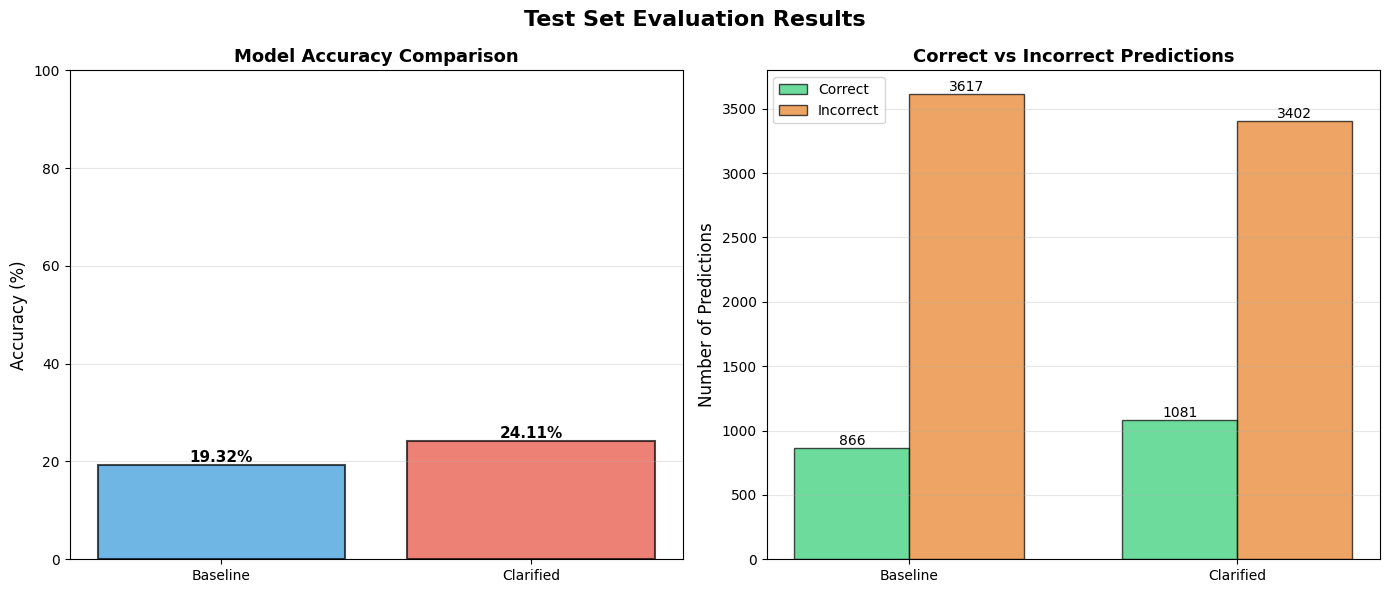


✓ Evaluation plot saved to: experiments/t5_models/test_evaluation_results.png


In [21]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Test Set Evaluation Results', fontsize=16, fontweight='bold')

# Plot 1: Accuracy Comparison
models = ['Baseline', 'Clarified']
accuracies = [baseline_acc, clarified_acc]
colors = ['#3498db', '#e74c3c']

bars = axes[0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Correct vs Incorrect Predictions
categories = ['Baseline', 'Clarified']
correct_counts = [baseline_correct, clarified_correct]
incorrect_counts = [baseline_total - baseline_correct, clarified_total - clarified_correct]

x = range(len(categories))
width = 0.35

bars1 = axes[1].bar([i - width/2 for i in x], correct_counts, width,
                    label='Correct', color='#2ecc71', alpha=0.7, edgecolor='black')
bars2 = axes[1].bar([i + width/2 for i in x], incorrect_counts, width,
                    label='Incorrect', color='#e67e22', alpha=0.7, edgecolor='black')

axes[1].set_ylabel('Number of Predictions', fontsize=12)
axes[1].set_title('Correct vs Incorrect Predictions', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'test_evaluation_results.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Evaluation plot saved to: {os.path.join(OUTPUT_DIR, 'test_evaluation_results.png')}")

## Error Analysis

**Purpose:** Analyze prediction errors to understand model behavior.

**What this does:**
- Identifies samples where models differ in predictions
- Finds cases where clarified model succeeds but baseline fails
- Finds cases where baseline succeeds but clarified fails
- Shows error patterns and improvement areas

**Analysis categories:**
1. Both correct
2. Both incorrect
3. Only baseline correct
4. Only clarified correct

In [22]:
# Perform error analysis
both_correct = 0
both_incorrect = 0
only_baseline_correct = 0
only_clarified_correct = 0

clarified_improvements = []
baseline_advantages = []

for i, (b_pred, c_pred, gt) in enumerate(zip(baseline_preds, clarified_preds, baseline_gts)):
    b_pred_norm = b_pred.strip().replace(" ", "")
    c_pred_norm = c_pred.strip().replace(" ", "")
    gt_norm = gt.strip().replace(" ", "")

    b_correct = (b_pred_norm == gt_norm)
    c_correct = (c_pred_norm == gt_norm)

    if b_correct and c_correct:
        both_correct += 1
    elif not b_correct and not c_correct:
        both_incorrect += 1
    elif b_correct and not c_correct:
        only_baseline_correct += 1
        baseline_advantages.append({
            'index': i,
            'input': test_baseline_samples[i]['input_text'][:100] + '...',
            'baseline_pred': b_pred,
            'clarified_pred': c_pred,
            'ground_truth': gt
        })
    else:  # clarified correct, baseline wrong
        only_clarified_correct += 1
        clarified_improvements.append({
            'index': i,
            'input': test_clarified_samples[i]['input_text'][:100] + '...',
            'baseline_pred': b_pred,
            'clarified_pred': c_pred,
            'ground_truth': gt
        })

print("\n" + "="*60)
print(" ERROR ANALYSIS")
print("="*60)

print(f"\n Prediction Agreement:")
print(f"   Both correct: {both_correct} ({both_correct/len(baseline_preds)*100:.1f}%)")
print(f"   Both incorrect: {both_incorrect} ({both_incorrect/len(baseline_preds)*100:.1f}%)")
print(f"   Only baseline correct: {only_baseline_correct} ({only_baseline_correct/len(baseline_preds)*100:.1f}%)")
print(f"   Only clarified correct: {only_clarified_correct} ({only_clarified_correct/len(baseline_preds)*100:.1f}%)")

print(f"\n Clarification Impact:")
print(f"   Cases where clarifications helped: {only_clarified_correct}")
print(f"   Cases where clarifications hurt: {only_baseline_correct}")
print(f"   Net improvement: {only_clarified_correct - only_baseline_correct} cases")

print("="*60)


 ERROR ANALYSIS

 Prediction Agreement:
   Both correct: 787 (17.6%)
   Both incorrect: 3323 (74.1%)
   Only baseline correct: 79 (1.8%)
   Only clarified correct: 294 (6.6%)

 Clarification Impact:
   Cases where clarifications helped: 294
   Cases where clarifications hurt: 79
   Net improvement: 215 cases


## Example Predictions - Clarification Improvements

**Purpose:** Show concrete examples where clarifications helped.

**What this displays:**
- Input text with entity markers
- Baseline model's (incorrect) prediction
- Clarified model's (correct) prediction
- Ground truth QID
- Highlights why clarifications made a difference

**Sample size:** Shows first 5 cases where clarifications improved results.

In [23]:
print("\n" + "="*60)
print(" EXAMPLES WHERE CLARIFICATIONS HELPED")
print("="*60)

num_examples = min(5, len(clarified_improvements))

if num_examples > 0:
    for i, example in enumerate(clarified_improvements[:num_examples], 1):
        print(f"\n{'─'*60}")
        print(f" Example {i}/{num_examples}")
        print(f"{'─'*60}")
        print(f"\n Input (first 200 chars):")
        print(f"   {example['input'][:200]}...")
        print(f"\n Baseline Prediction: {example['baseline_pred']} ✗")
        print(f" Clarified Prediction: {example['clarified_pred']} ✓")
        print(f" Ground Truth: {example['ground_truth']}")
else:
    print("\n No cases where clarifications improved over baseline.")

print("\n" + "="*60)


 EXAMPLES WHERE CLARIFICATIONS HELPED

────────────────────────────────────────────────────────────
 Example 1/5
────────────────────────────────────────────────────────────

 Input (first 200 chars):
   link entity:  advantage of a misdirected defensive header to lob the ball over the advancing Chinese......

 Baseline Prediction: Q1530 ✗
 Clarified Prediction: Q15180 ✓
 Ground Truth: Q15180

────────────────────────────────────────────────────────────
 Example 2/5
────────────────────────────────────────────────────────────

 Input (first 200 chars):
   link entity: RUGBY UNION - CUTTITTA BACK FOR ITALY AFTER A YEAR . [START_ENT] ROME [END_ENT] [CLARIF......

 Baseline Prediction: Q21 ✗
 Clarified Prediction: Q220 ✓
 Ground Truth: Q220

────────────────────────────────────────────────────────────
 Example 3/5
────────────────────────────────────────────────────────────

 Input (first 200 chars):
   link entity: 2-06 Results of the World Cup freestyle skiing moguls competition on Fri

## Example Predictions - Baseline Advantages

**Purpose:** Show cases where baseline outperformed clarified model.

**What this displays:**
- Examples where adding clarifications hurt performance
- Baseline model's (correct) prediction
- Clarified model's (incorrect) prediction
- Ground truth QID
- Helps identify when clarifications might be confusing

**Analysis:** Understanding failure modes for future improvements.

In [24]:
print("\n" + "="*60)
print(" EXAMPLES WHERE BASELINE WAS BETTER")
print("="*60)

num_examples = min(3, len(baseline_advantages))

if num_examples > 0:
    for i, example in enumerate(baseline_advantages[:num_examples], 1):
        print(f"\n{'─'*60}")
        print(f" Example {i}/{num_examples}")
        print(f"{'─'*60}")
        print(f"\n Input (first 200 chars):")
        print(f"   {example['input'][:200]}...")
        print(f"\n Baseline Prediction: {example['baseline_pred']} ✓")
        print(f" Clarified Prediction: {example['clarified_pred']} ✗")
        print(f" Ground Truth: {example['ground_truth']}")
else:
    print("\n No cases where baseline outperformed clarified model.")

print("\n" + "="*60)


 EXAMPLES WHERE BASELINE WAS BETTER

────────────────────────────────────────────────────────────
 Example 1/3
────────────────────────────────────────────────────────────

 Input (first 200 chars):
   link entity: CRICKET - [START_ENT] PAKISTAN [END_ENT] V NEW ZEALAND ONE-DAY SCOREBOARD . [ CORRECTED......

 Baseline Prediction: Q182538 ✓
 Clarified Prediction: Q361 ✗
 Ground Truth: Q182538

────────────────────────────────────────────────────────────
 Example 2/3
────────────────────────────────────────────────────────────

 Input (first 200 chars):
   link entity: CRICKET - PAKISTAN V NEW ZEALAND ONE-DAY SCOREBOARD . [ CORRECTED 14:06 GMT ] SIALKOT ,......

 Baseline Prediction: Q182538 ✓
 Clarified Prediction: Q142555 ✗
 Ground Truth: Q182538

────────────────────────────────────────────────────────────
 Example 3/3
────────────────────────────────────────────────────────────

 Input (first 200 chars):
   link entity: CRICKET - PAKISTAN V NEW ZEALAND ONE-DAY SCOREBOARD . [ CORRECT

## Save Evaluation Results

**Purpose:** Save detailed evaluation results to JSON for further analysis.

**What this saves:**
- Complete predictions and ground truths
- Accuracy metrics for both models
- Error analysis breakdown
- Example cases (improvements and regressions)
- Timestamp and configuration

**Output file:** `experiments/t5_models/evaluation_results.json`

In [25]:
from datetime import datetime

# Prepare evaluation results
evaluation_results = {
    'timestamp': datetime.now().isoformat(),
    'test_set_size': len(baseline_preds),
    'baseline': {
        'accuracy': baseline_acc,
        'correct': baseline_correct,
        'total': baseline_total,
        'predictions': baseline_preds[:100]  # Save first 100 for space
    },
    'clarified': {
        'accuracy': clarified_acc,
        'correct': clarified_correct,
        'total': clarified_total,
        'predictions': clarified_preds[:100]
    },
    'comparison': {
        'absolute_improvement': improvement,
        'relative_improvement_pct': improvement_pct,
        'both_correct': both_correct,
        'both_incorrect': both_incorrect,
        'only_baseline_correct': only_baseline_correct,
        'only_clarified_correct': only_clarified_correct,
        'net_improvement_cases': only_clarified_correct - only_baseline_correct
    },
    'examples': {
        'clarification_improvements': clarified_improvements[:5],
        'baseline_advantages': baseline_advantages[:3]
    }
}

# Save to JSON
results_path = os.path.join(OUTPUT_DIR, 'evaluation_results_sample.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(evaluation_results, f, indent=2, ensure_ascii=False)

print(f"\n✓ Evaluation results saved to: {results_path}")

print("\n" + "="*60)
print(" EVALUATION COMPLETE")
print("="*60)
print(f"\n Final Summary:")
print(f"   Baseline Accuracy: {baseline_acc:.2f}%")
print(f"   Clarified Accuracy: {clarified_acc:.2f}%")
print(f"   Improvement: {improvement:+.2f}%")
print(f"\n All results saved to: {OUTPUT_DIR}/")
print("="*60)


✓ Evaluation results saved to: experiments/t5_models/evaluation_results_sample.json

 EVALUATION COMPLETE

 Final Summary:
   Baseline Accuracy: 19.32%
   Clarified Accuracy: 24.11%
   Improvement: +4.80%

 All results saved to: experiments/t5_models/
